In [48]:
import random
import time
import statistics
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [50]:
def w_interval(ints):
    ints.sort(key=lambda x: x[1])
    n = len(ints)
    best_w = [0]*n
    prev_int = [-1]*n

    for cur in range(n):
        s, f, w = ints[cur]

        prev = cur-1
        while prev >= 0 and ints[prev][1] > s:
            prev -= 1

        take = w + (best_w[prev] if prev >= 0 else 0)
        skip = best_w[cur-1] if cur else 0

        if take > skip:
            best_w[cur] = take
            prev_int[cur] = prev
        else:
            best_w[cur] = skip
            prev_int[cur] = cur-1

    chosen = []
    i = n-1

    while i >= 0:
        if prev_int[i] == i-1:
            i -= 1
        else:
            chosen.append(ints[i])
            i = prev_int[i]

    return best_w[-1]

def make_intervals(n):
    arr = []
    for _ in range(n):
        s = random.randint(0, 9999)
        f = random.randint(1, 10000)
        w = random.randint(1, 10)
        arr.append((s, f, w))
    return arr


def measure(n):
    data = make_intervals(n)
    t1 = time.perf_counter()
    w_interval(data)
    return time.perf_counter() - t1

In [82]:
def run_tests(n, k):
    times = []
    for _ in range(k):
        times.append(measure(n))
    return statistics.mean(times), statistics.stdev(times), times


def experiment(sizes, k):
    results = []
    all_times = {}

    for n in sizes:
        mean, std, times = run_tests(n, k)
        print("n =", n, "среднее =", mean, "СКО =", std)
        results.append((n, mean, std))
        all_times[n] = times
    return results, all_times

In [84]:
def plot_time(results):
    x = [r[0] for r in results]
    mean = [r[1] for r in results]
    std = [r[2] for r in results]

    low = [m - 2*s for m, s in zip(mean, std)]
    high = [m + 2*s for m, s in zip(mean, std)]

    plt.plot(x, mean, marker='o', label="Среднее время")
    plt.fill_between(x, low, high, alpha=0.25, label="±2 СКО")

    plt.xlabel("Размер")
    plt.ylabel("Время")
    plt.title("Зависимость времени работы алгоритма")

    plt.legend()
    plt.grid(True)
    plt.show()

In [86]:
def plot_hist(times, n):
    plt.hist(times, bins=12, edgecolor='black')

    plt.xlabel("Время выполнения (сек)")
    plt.ylabel("Количество запусков")
    plt.title("Гистограмма времени при n = " + str(n))

    plt.grid(True)
    plt.show()

def test_normal(times, n):
    _, p = shapiro(times)
    if p > 0.05:
        print("Распределение похоже на нормальное")
    else:
        print("Распределение не нормальное")

In [88]:
def time_check(t):
    if t < 0.01:
        return "время очень хорошее"
    if t < 0.1:
        return "время приемлемое"
    return "время большое"

n = 100 среднее = 6.855172105133534e-05 СКО = 3.153151972996727e-05
n = 200 среднее = 0.00021469001425430178 СКО = 1.9340004919906856e-05
n = 400 среднее = 0.000835850778967142 СКО = 7.837792900171645e-05
n = 600 среднее = 0.0018467241432517767 СКО = 0.00014311526852221618
n = 800 среднее = 0.003273412461858243 СКО = 0.00022070111352716097
n = 1000 среднее = 0.004995733299292624 СКО = 0.00021213179204585946
n = 1200 среднее = 0.007158062502276153 СКО = 0.0002774168083159642
n = 1400 среднее = 0.00972922584041953 СКО = 0.00039737518462031567
n = 1600 среднее = 0.012727778353728354 СКО = 0.0003777269223439827
n = 1800 среднее = 0.016188767421990633 СКО = 0.0005951929315958602
n = 2000 среднее = 0.020168556671123952 СКО = 0.0007435499947141971


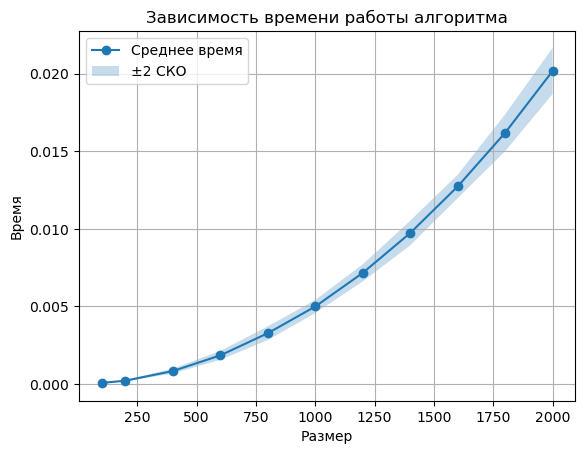

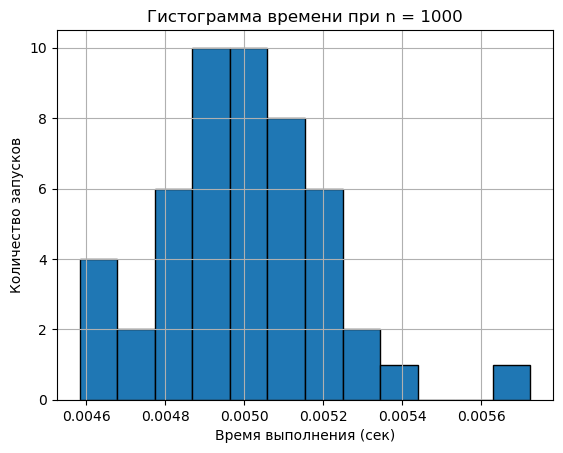

Распределение похоже на нормальное
Оценка времени: время очень хорошее


In [90]:
sizes = [100,200,400,600,800,1000,1200,1400,1600,1800,2000]

results, all_times = experiment(sizes, 50)

plot_time(results)

n_choice = 1000
times = all_times[n_choice]

plot_hist(times, n_choice)

test_normal(times, n_choice)

print("Оценка времени:", time_check(statistics.mean(times)))